# Numerical Integration

## Riemann Sums, Midpoint, Trapezoidal & Simpson's Rule

This notebook implements and compares the most common methods for
approximating a definite integral

$$
I = \int_a^b f(x)\,\mathrm{d}x
$$

using a finite number of function evaluations.

| Method | Idea | Error order |
|--------|------|:-----------:|
| Left / Right Riemann | Rectangles at interval edges | $O(h)$ |
| Midpoint Rule | Rectangles at interval centres | $O(h^2)$ |
| Trapezoidal Rule | Linear interpolation (trapezoids) | $O(h^2)$ |
| Simpson's Rule | Quadratic interpolation (parabolas) | $O(h^4)$ |

where $h = (b-a)/N$ is the sub-interval width.

---

## 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 2 — Test Functions

Each function comes with its known antiderivative $F(x)$
so we can compute the **exact** integral $I = F(b) - F(a)$.

In [2]:
FUNCTIONS = {
    "poly_sin": {
        "label": r"$0.1x^2 + \sin(x) + 2$",
        "f": lambda x: 0.1 * x**2 + np.sin(x) + 2,
        "F": lambda x: (0.1 / 3) * x**3 - np.cos(x) + 2 * x,
    },
    "exp": {
        "label": r"$e^{x/3}$",
        "f": lambda x: np.exp(x / 3),
        "F": lambda x: 3 * np.exp(x / 3),
    },
    "parabola": {
        "label": r"$-0.2(x-5)^2 + 7$",
        "f": lambda x: -0.2 * (x - 5)**2 + 7,
        "F": lambda x: -0.2 * (x - 5)**3 / 3 + 7 * x,
    },
    "cos": {
        "label": r"$\cos(x/2) + 3$",
        "f": lambda x: np.cos(x / 2) + 3,
        "F": lambda x: 2 * np.sin(x / 2) + 3 * x,
    },
}


def exact_integral(key, a, b):
    """Exact value of the integral via the antiderivative."""
    F = FUNCTIONS[key]["F"]
    return F(b) - F(a)

## 3 — Integration Methods

### 3.1 Left and Right Riemann Sums

$$
I_{\text{left}} = \sum_{i=0}^{N-1} f(x_i)\,\Delta x
\qquad\qquad
I_{\text{right}} = \sum_{i=0}^{N-1} f(x_{i+1})\,\Delta x
$$

### 3.2 Midpoint Rule

$$
I_{\text{mid}} = \sum_{i=0}^{N-1} f\!\left(\frac{x_i + x_{i+1}}{2}\right) \Delta x
$$

### 3.3 Trapezoidal Rule

$$
I_{\text{trap}} = \sum_{i=0}^{N-1} \frac{f(x_i) + f(x_{i+1})}{2}\,\Delta x
$$

### 3.4 Simpson's Rule

Requires $N$ to be **even**. Groups sub-intervals in pairs and fits
a parabola through three points:

$$
I_{\text{simp}} = \frac{\Delta x}{3}
\Big[f(a) + 4\!\sum_{\text{odd }i} f(x_i)
+ 2\!\sum_{\text{even }i} f(x_i) + f(b)\Big]
$$

In [3]:
def integrate(f, a, b, N, method="left"):
    """
    Approximate the integral of f from a to b using N sub-intervals.

    Parameters
    ----------
    f      : callable – the integrand
    a, b   : float    – integration bounds
    N      : int      – number of sub-intervals
    method : str      – 'left', 'right', 'mid', 'trap', or 'simp'

    Returns
    -------
    float – approximate value of the integral
    """
    if method == "simp" and N % 2 != 0:
        N += 1                        # Simpson requires even N

    dx = (b - a) / N
    x  = np.linspace(a, b, N + 1)     # N+1 grid points

    if method == "left":
        return np.sum(f(x[:-1])) * dx

    elif method == "right":
        return np.sum(f(x[1:])) * dx

    elif method == "mid":
        x_mid = 0.5 * (x[:-1] + x[1:])
        return np.sum(f(x_mid)) * dx

    elif method == "trap":
        y = f(x)
        return np.sum((y[:-1] + y[1:]) / 2) * dx

    elif method == "simp":
        # Composite Simpson's 1/3 rule
        y = f(x)
        return (dx / 3) * (y[0] + y[-1]
                           + 4 * np.sum(y[1:-1:2])
                           + 2 * np.sum(y[2:-2:2]))
    else:
        raise ValueError(f"Unknown method: {method}")

## 4 — Visual Comparison of Methods

The plot below draws the geometric shapes (rectangles, trapezoids,
or parabolic arcs) that each method uses to approximate the area.

In [4]:
def plot_method(f, a, b, N, method, label="f(x)", ax=None):
    """
    Visualise a single integration method: draw the function curve
    and the geometric approximation shapes.
    """
    if method == "simp" and N % 2 != 0:
        N += 1

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    dx = (b - a) / N
    x_fine = np.linspace(a, b, 500)

    # Smooth function curve
    ax.plot(x_fine, f(x_fine), "b-", lw=2, label=label, zorder=5)

    # Draw approximation shapes
    for i in range(N):
        xi  = a + i * dx
        xi1 = a + (i + 1) * dx

        if method == "left":
            h = f(xi)
            rect = patches.Rectangle((xi, 0), dx, h,
                       edgecolor="#7c3aed", facecolor="#7c3aed",
                       alpha=0.20, lw=1)
            ax.add_patch(rect)

        elif method == "right":
            h = f(xi1)
            rect = patches.Rectangle((xi, 0), dx, h,
                       edgecolor="#7c3aed", facecolor="#7c3aed",
                       alpha=0.20, lw=1)
            ax.add_patch(rect)

        elif method == "mid":
            h = f(0.5 * (xi + xi1))
            rect = patches.Rectangle((xi, 0), dx, h,
                       edgecolor="#7c3aed", facecolor="#7c3aed",
                       alpha=0.20, lw=1)
            ax.add_patch(rect)

        elif method == "trap":
            trap = plt.Polygon(
                [(xi, 0), (xi, f(xi)), (xi1, f(xi1)), (xi1, 0)],
                closed=True, edgecolor="#7c3aed",
                facecolor="#7c3aed", alpha=0.20, lw=1,
            )
            ax.add_patch(trap)

        elif method == "simp" and i % 2 == 0 and i + 2 <= N:
            # Draw parabolic arc through 3 points
            x0, x1, x2 = xi, xi + dx, xi + 2 * dx
            y0, y1, y2 = f(x0), f(x1), f(x2)
            xs = np.linspace(x0, x2, 50)
            # Lagrange interpolation through (x0,y0), (x1,y1), (x2,y2)
            ys = (y0 * (xs - x1) * (xs - x2) / ((x0 - x1) * (x0 - x2))
                + y1 * (xs - x0) * (xs - x2) / ((x1 - x0) * (x1 - x2))
                + y2 * (xs - x0) * (xs - x1) / ((x2 - x0) * (x2 - x1)))
            ax.fill_between(xs, 0, ys, color="#7c3aed", alpha=0.20)
            ax.plot(xs, ys, color="#7c3aed", lw=1, alpha=0.5)

    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$f(x)$")

    return ax

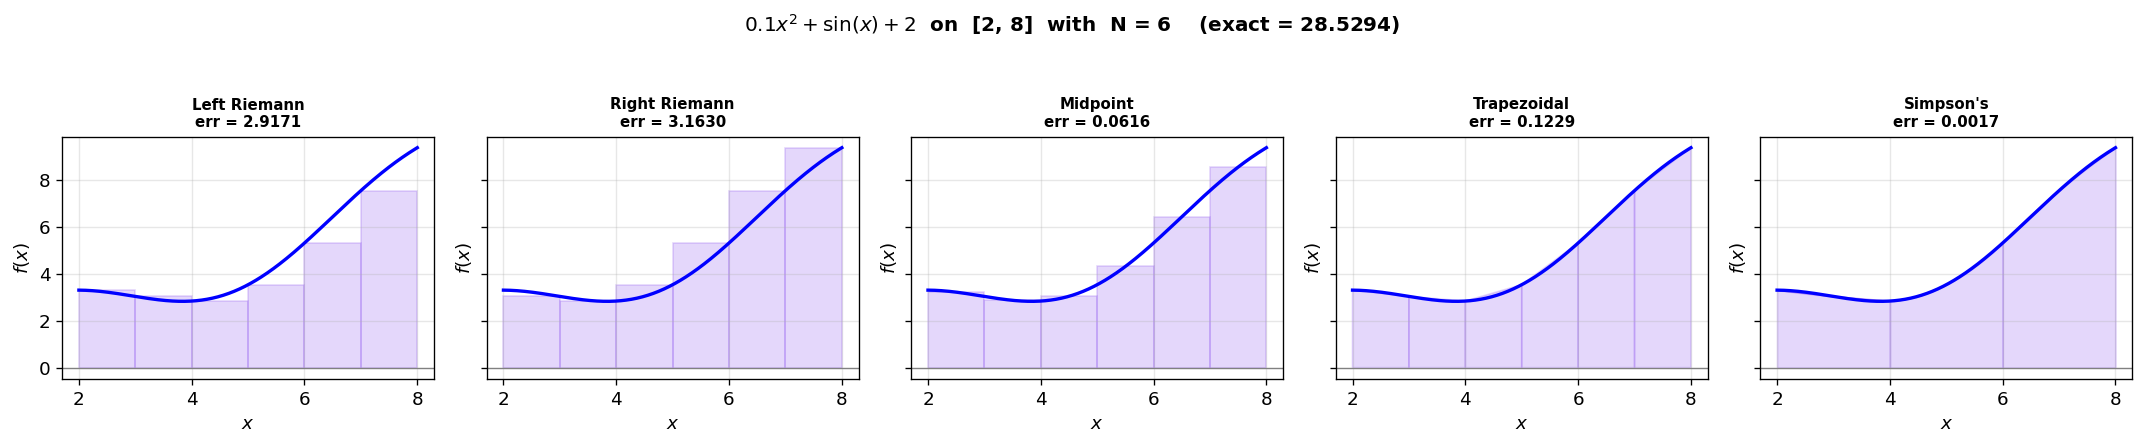

In [5]:
# Compare all five methods side by side
func  = FUNCTIONS["poly_sin"]
f     = func["f"]
a, b  = 2, 8
N     = 6
exact = exact_integral("poly_sin", a, b)

methods = ["left", "right", "mid", "trap", "simp"]
titles  = ["Left Riemann", "Right Riemann", "Midpoint",
           "Trapezoidal", "Simpson's"]

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)

for ax, m, title in zip(axes, methods, titles):
    plot_method(f, a, b, N, m, ax=ax)
    approx = integrate(f, a, b, N, m)
    err    = abs(exact - approx)
    ax.set_title(f"{title}\nerr = {err:.4f}", fontsize=9, fontweight="bold")

fig.suptitle(
    f"{func['label']}  on  [{a}, {b}]  with  N = {N}    "
    f"(exact = {exact:.4f})",
    fontsize=12, fontweight="bold", y=1.05,
)
fig.tight_layout()
plt.show()

## 5 — Effect of Increasing N

Watch how the rectangles / trapezoids get thinner and the
approximation tightens as $N$ grows.

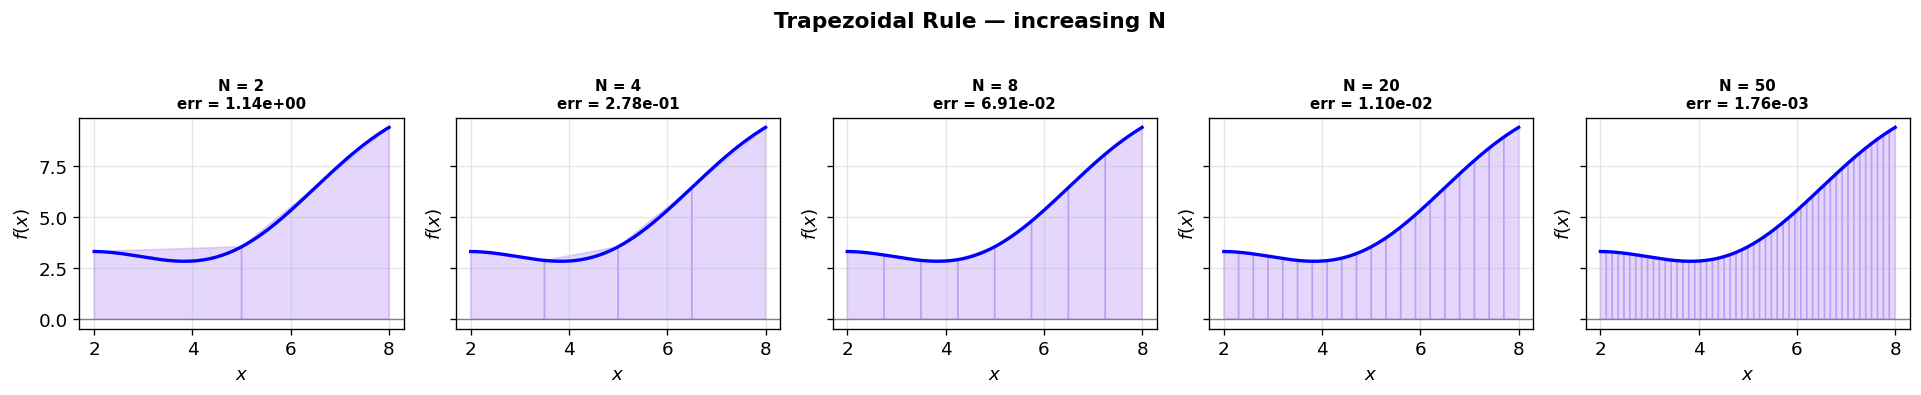

In [6]:
f     = FUNCTIONS["poly_sin"]["f"]
exact = exact_integral("poly_sin", 2, 8)

Ns   = [2, 4, 8, 20, 50]
meth = "trap"

fig, axes = plt.subplots(1, len(Ns), figsize=(16, 3.2), sharey=True)

for ax, N in zip(axes, Ns):
    plot_method(f, 2, 8, N, meth, ax=ax)
    approx = integrate(f, 2, 8, N, meth)
    ax.set_title(f"N = {N}\nerr = {abs(exact - approx):.2e}",
                 fontsize=9, fontweight="bold")

fig.suptitle(f"Trapezoidal Rule — increasing N",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 6 — Convergence Study

The error should decrease as $N$ increases. The **rate** at which
it decreases reveals the method's *order of accuracy*:

| Method | Expected slope on log–log plot |
|--------|:----:|
| Left / Right Riemann | $-1$ |
| Midpoint | $-2$ |
| Trapezoidal | $-2$ |
| Simpson's | $-4$ |

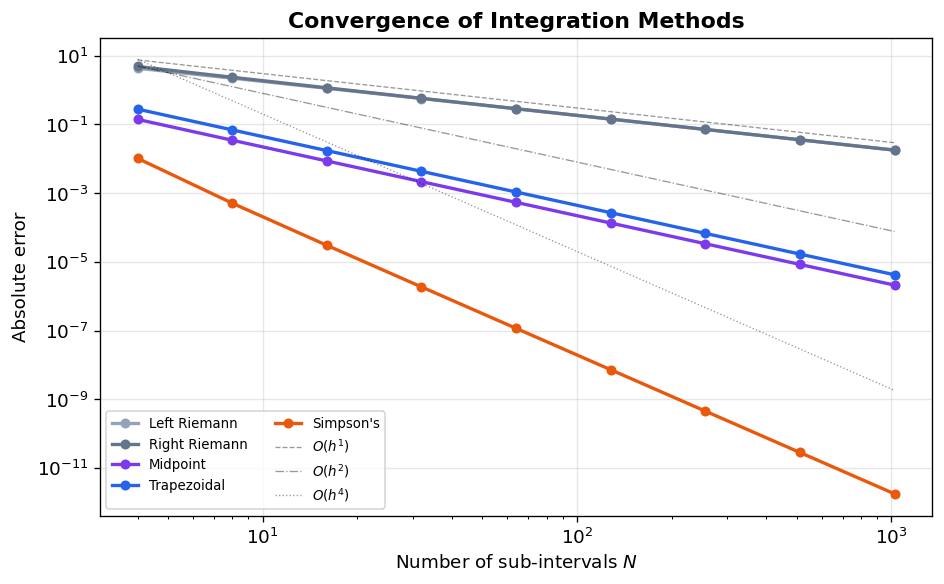

In [7]:
f     = FUNCTIONS["poly_sin"]["f"]
exact = exact_integral("poly_sin", 2, 8)

N_values = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024])
methods  = ["left", "right", "mid", "trap", "simp"]
colors   = ["#94a3b8", "#64748b", "#7c3aed", "#2563eb", "#ea580c"]
labels   = ["Left Riemann", "Right Riemann", "Midpoint",
            "Trapezoidal", "Simpson's"]

fig, ax = plt.subplots(figsize=(8, 5))

for m, col, lab in zip(methods, colors, labels):
    errors = [abs(exact - integrate(f, 2, 8, N, m)) for N in N_values]
    ax.loglog(N_values, errors, "o-", color=col, lw=2, markersize=5, label=lab)

# Reference slopes
N_ref = N_values.astype(float)
ax.loglog(N_ref, 30 / N_ref,      "k--", lw=0.8, alpha=0.4, label="$O(h^1)$")
ax.loglog(N_ref, 80 / N_ref**2,   "k-.", lw=0.8, alpha=0.4, label="$O(h^2)$")
ax.loglog(N_ref, 2000 / N_ref**4, "k:",  lw=0.8, alpha=0.4, label="$O(h^4)$")

ax.set_xlabel("Number of sub-intervals $N$")
ax.set_ylabel("Absolute error")
ax.set_title("Convergence of Integration Methods", fontweight="bold")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

The slopes confirm the theoretical orders: Left/Right follow the
$O(h)$ line (slope $-1$), Midpoint and Trapezoidal follow $O(h^2)$
(slope $-2$), and Simpson's follows $O(h^4)$ (slope $-4$).

## 7 — Accuracy Table

In [8]:
f     = FUNCTIONS["poly_sin"]["f"]
exact = exact_integral("poly_sin", 2, 8)

print(f"Exact integral = {exact:.10f}")
print()
print(f"{'N':>6}  {'Left':>12}  {'Right':>12}  {'Midpoint':>12}  "
      f"{'Trapez.':>12}  {'Simpson':>12}")
print("-" * 75)

for N in [4, 8, 16, 32, 64, 256]:
    vals = [integrate(f, 2, 8, N, m) for m in methods]
    errs = [abs(exact - v) for v in vals]
    print(f"{N:>6}", end="")
    for e in errs:
        print(f"  {e:>12.2e}", end="")
    print()

Exact integral = 28.5293531973

     N          Left         Right      Midpoint       Trapez.       Simpson
---------------------------------------------------------------------------
     4      4.28e+00      4.84e+00      1.40e-01      2.78e-01      1.03e-02
     8      2.21e+00      2.35e+00      3.46e-02      6.91e-02      5.10e-04
    16      1.12e+00      1.16e+00      8.62e-03      1.72e-02      3.02e-05
    32      5.66e-01      5.74e-01      2.15e-03      4.31e-03      1.87e-06
    64      2.84e-01      2.86e-01      5.39e-04      1.08e-03      1.16e-07
   256      7.12e-02      7.13e-02      3.37e-05      6.73e-05      4.54e-10


## 8 — Comparison Across Different Functions

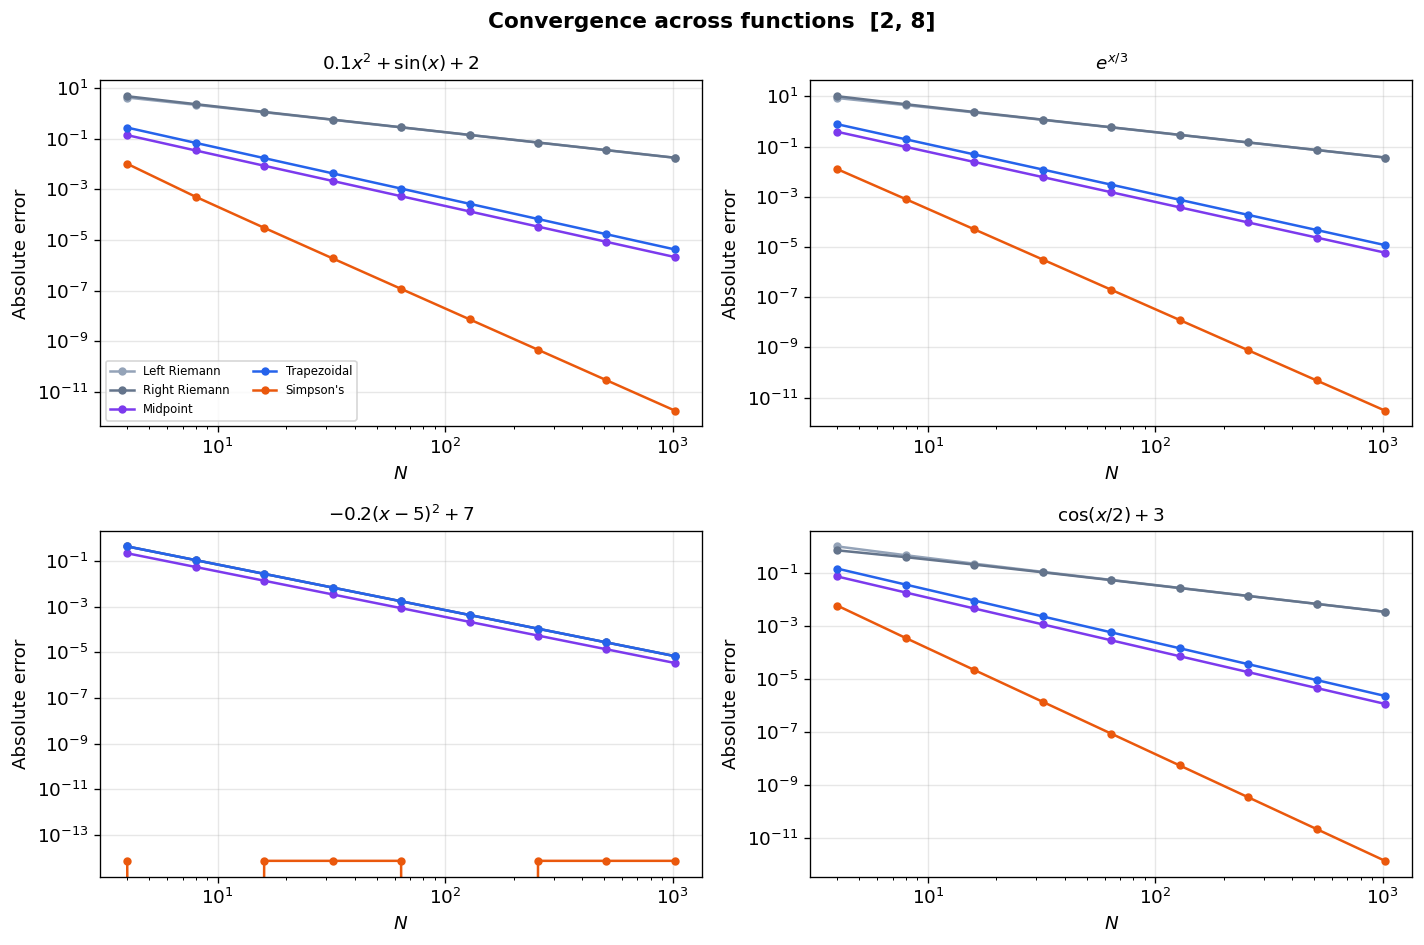

In [9]:
a, b = 2, 8

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (key, func) in zip(axes.flat, FUNCTIONS.items()):
    f     = func["f"]
    exact = exact_integral(key, a, b)

    for m, col, lab in zip(methods, colors, labels):
        errors = [abs(exact - integrate(f, a, b, N, m)) for N in N_values]
        ax.loglog(N_values, errors, "o-", color=col, lw=1.5,
                  markersize=4, label=lab)

    ax.set_title(func["label"], fontsize=11, fontweight="bold")
    ax.set_xlabel("$N$")
    ax.set_ylabel("Absolute error")

axes[0, 0].legend(fontsize=7, ncol=2)
fig.suptitle(f"Convergence across functions  [{a}, {b}]",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 9 — Why Simpson's Rule is Special

Simpson's rule fits a **parabola** through every group of three
consecutive points. Because it integrates polynomials up to
degree 3 exactly (even though it's built from degree-2 fits!),
it has $O(h^4)$ accuracy — two orders better than the trapezoidal rule
for essentially the same computational cost.

Let's demonstrate: for a **cubic** polynomial, Simpson's gives the
exact answer with just $N = 2$.

In [10]:
# f(x) = x³ - 2x² + x + 1   (a cubic polynomial)
f_cubic = lambda x: x**3 - 2*x**2 + x + 1
# Exact antiderivative: x⁴/4 - 2x³/3 + x²/2 + x
F_cubic = lambda x: x**4/4 - 2*x**3/3 + x**2/2 + x

a, b = 0, 3
exact = F_cubic(b) - F_cubic(a)

print(f"Exact integral of x³ - 2x² + x + 1 on [0, 3] = {exact:.6f}")
print()
print(f"{'Method':<15} {'N=2':>12} {'N=4':>12} {'N=8':>12}")
print("-" * 55)
for m, lab in zip(methods, labels):
    row = f"{lab:<15}"
    for N in [2, 4, 8]:
        err = abs(exact - integrate(f_cubic, a, b, N, m))
        row += f" {err:>12.2e}"
    print(row)

print()
print("→ Simpson's gives ZERO error even with N = 2!")

Exact integral of x³ - 2x² + x + 1 on [0, 3] = 9.750000

Method                   N=2          N=4          N=8
-------------------------------------------------------
Left Riemann        6.19e+00     3.80e+00     2.07e+00
Right Riemann       1.18e+01     5.20e+00     2.43e+00
Midpoint            1.41e+00     3.52e-01     8.79e-02
Trapezoidal         2.81e+00     7.03e-01     1.76e-01
Simpson's           0.00e+00     0.00e+00     0.00e+00

→ Simpson's gives ZERO error even with N = 2!


## 10 — Practical Comparison: Accuracy vs. Cost

How many function evaluations does each method need to achieve
a target accuracy?

In [ ]:
f     = FUNCTIONS["exp"]["f"]
exact = exact_integral("exp", 2, 8)
target_errors = [1e-2, 1e-4, 1e-6, 1e-8]

print(f"Function: e^(x/3) on [2, 8],  exact = {exact:.8f}")
print()
print(f"{'Target error':<14}", end="")
for lab in labels:
    print(f"  {lab:>14}", end="")
print()
print("-" * 88)

for target in target_errors:
    print(f"< {target:<12.0e}", end="")
    for m in methods:
        # Find smallest N that achieves the target
        for N in range(2, 100_001, 2):
            if abs(exact - integrate(f, 2, 8, N, m)) < target:
                print(f"  {'N=' + str(N):>14}", end="")
                break
        else:
            print(f"  {'>100k':>14}", end="")
    print()

Function: e^(x/3) on [2, 8],  exact = 37.33254616

Target error      Left Riemann   Right Riemann        Midpoint     Trapezoidal       Simpson's
----------------------------------------------------------------------------------------
< 1e-02                 N=3734          N=3734            N=26            N=36             N=6
< 1e-04                  >100k

## 11 — Notes for Students

### Key take-aways

1. **All methods converge** — as $N \to \infty$ every method
   approaches the exact integral. The question is *how fast*.

2. **Order matters enormously** — Doubling $N$ halves the error for
   a 1st-order method, quarters it for 2nd-order, and reduces it by a
   factor of 16 for 4th-order (Simpson's).

3. **Midpoint ≈ Trapezoidal** — Both are $O(h^2)$, but the midpoint
   rule often has a smaller constant. The trapezoidal rule is the
   *average* of the left and right Riemann sums.

4. **Simpson's is remarkably efficient** — It integrates cubics
   exactly and reaches machine precision with modest $N$ for smooth
   functions. It's the default choice in many engineering tools.

5. **Smoothness matters** — All error estimates assume the integrand
   is sufficiently smooth. For functions with kinks or discontinuities,
   high-order methods may lose their advantage.

### Exercises

1. Implement the **composite Simpson's 3/8 rule** (uses groups of 3
   sub-intervals with a cubic fit). What is its error order?

2. Verify numerically that the trapezoidal rule equals the
   *average* of the left and right Riemann sums:
   $I_{\text{trap}} = \tfrac{1}{2}(I_{\text{left}} + I_{\text{right}})$.

3. Integrate $f(x) = |x|$ on $[-1, 1]$ (a function with a kink at
   $x=0$). Do the convergence orders change compared to smooth functions?

4. Use the convergence plot to estimate the observed order of each
   method by computing the slope $p \approx \log(e_N/e_{2N})/\log 2$.

5. Compare `scipy.integrate.quad` with your Simpson's implementation
   for the function $e^{x/3}$. How many function evaluations does
   `quad` use to achieve the same accuracy?